# Лабораторная работа №3
## Обработка бинарных изображений. Морфология.

1. Открыть изображение, преобразовать в бинарное. Или создать бинарное изображение средствами OpenCV.
2. Зашумить изображение импульсным шумом с вероятностью p (по вариантам).
  *   Вход: изображение из пункта 1.
  *   Вывод: зашумленное изображение.
3. Написать функции реализации эрозии и дилатации.

> Функции вида fun(Image, struct)
Где struct  - структурный элемент в виде матрицы

4. Выполнить операции эрозии и дилатации для зашумленного изображения со структурным элементом заданным по вариантам.
  *   Вход: изображение из пункта 2.
  *   Вывод: Исходное (из пункта 1), зашумленное (из пункта 2) и  изображения после эрозии и дилатации.
5. Отфильтровать зашумленное изображение при помощи морфологических операций вскрытия и закрытия (структурный элемент задан по вариантам).
Подсчитать коэффициент шума для результа фильтрации.
  *   Вход: изображение из пункта 2.
  *   Вывод:  исходное (из пункта 1), зашумленное (из пункта 2) и  изображения после вскрытия и закрытия. Коэффициент шума.
  *   Коэффициент шума считать как количество несовпавших пикселей между отфильтрованным изображением и исходным (не зашумленным) из пункта 1.

6. На исходном изображении  с помощью морфологических операций выделить контур объекта. Выяснить, когда контур получается внешним, внутренним, четырёхсвязным, восьмисвязным.
  *   Вход: изображение из пункта 1.
  *   Вывод: исходное изображение, изображение с выделенными контурами.

7. На исходном изображении  с помощью морфологических операций выделить горизонтальные и вертикальные контуры объекта.
  *   Вход: изображение из пункта 1.
  *   Вывод: исходное изображение, изображение с выделенными горизонтальными контурами, изображение с выделенными вертикальными контурами.




*Для работы с изображением использовать OpenCV (открытие, сохранение и т.д.). Для визуализации можно использовать matplotlib. Все необходимые для задания функции реализовавать самим, а не использовать готовые в OpenCV, если не указано обратного.*




---



> По всем вопросам писать на почту  ***cybersouls@yandex.ru*** или в ЛС в VK/tg


**Вариант:** 2 (p=0.2, квадрат 5×5)

## 1. Создание бинарного изображения с простыми фигурами

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

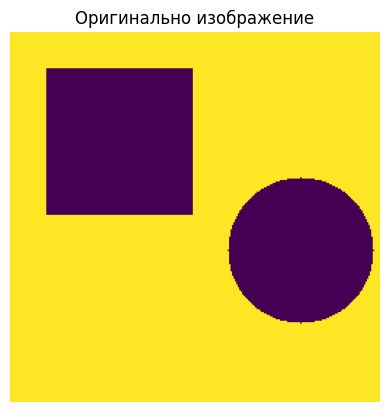

In [2]:
width, height = 255, 255
_, binary_image = cv2.threshold(np.ones((width, height)) * 255, 127, 255, cv2.THRESH_BINARY)

square_side = 100
square_color = 0
square_start_point = (25, 25)
square_end_point = (25 + square_side, 25 + square_side)
cv2.rectangle(binary_image, square_start_point, square_end_point, square_color, -1)

circle_radius = 50
circle_center = (200, 150)
circle_color = 0
cv2.circle(binary_image, circle_center, circle_radius, circle_color, -1)

plt.imshow(binary_image)
plt.title("Оригинально изображение")
plt.axis('off')
plt.show()
image = np.asarray(binary_image).astype(int)

## 2. Зашумление изображения импульсным шумом (p = 0.2)

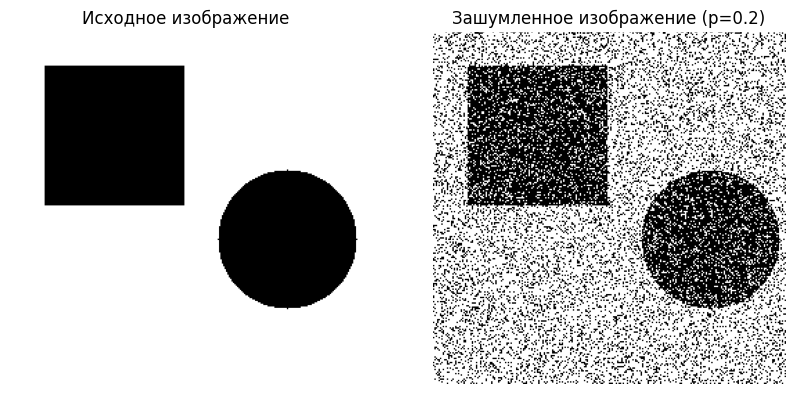

In [3]:
def add_noise(image: np.ndarray, probability: float) -> np.ndarray:
    rows, cols = image.shape
    noise = (np.random.rand(rows, cols) < probability) * 255
    res = image + noise
    res[res > 255] = 0
    return res

noisy_image = add_noise(image, probability=0.2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(noisy_image, cmap='gray')
plt.title('Зашумленное изображение (p=0.2)')
plt.axis('off')
plt.show()

## 3. Реализация функций эрозии и дилатации

In [4]:
def erosion2(image: np.ndarray, struct: np.ndarray) -> np.ndarray:
    res_img = np.copy(image)
    rows, cols = image.shape
    w_r, w_c = struct.shape

    border_r = w_r // 2
    border_c = w_c // 2

    padded_image = np.pad(image, ((border_r, border_r), (border_c, border_c)),
                          'constant', constant_values=255)

    for i in range(rows):
        for j in range(cols):
            local_window = padded_image[i:i + w_r, j:j + w_c]
            res_img[i, j] = np.min(local_window[struct == 1])

    return res_img


def dilatation2(image: np.ndarray, struct: np.ndarray) -> np.ndarray:
    res_img = np.copy(image)
    rows, cols = image.shape
    w_r, w_c = struct.shape

    border_r = w_r // 2
    border_c = w_c // 2

    padded_image = np.pad(image, ((border_r, border_r), (border_c, border_c)),
                          'constant', constant_values=0)

    for i in range(rows):
        for j in range(cols):
            local_window = padded_image[i:i + w_r, j:j + w_c]
            res_img[i, j] = np.max(local_window[struct == 1])

    return res_img

## 4. Эрозия и дилатация с структурным элементом: квадрат 5×5

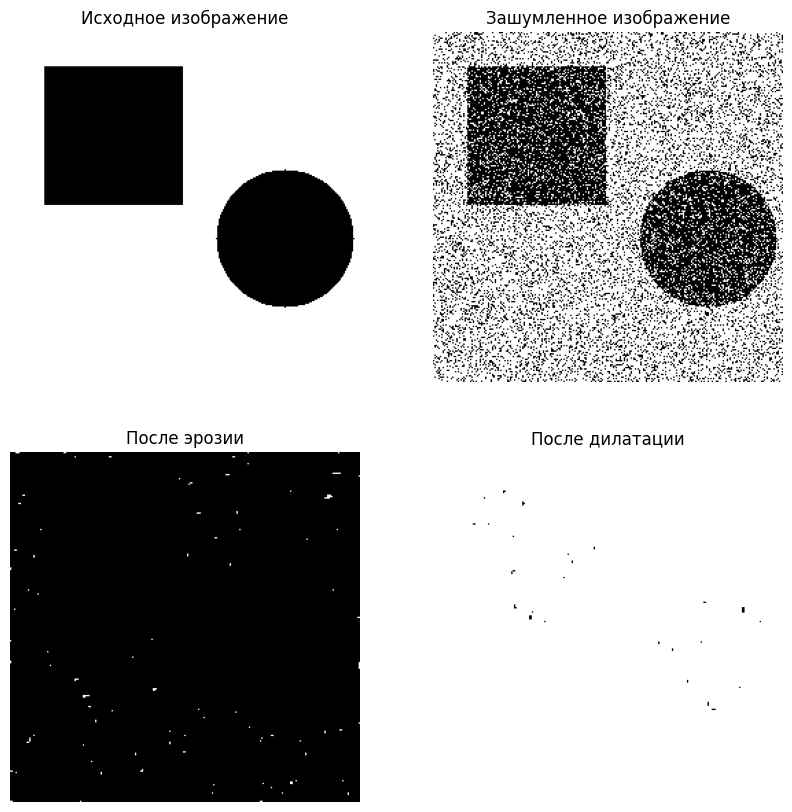

In [5]:
struct = np.array([
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1]
])

after_erosion = erosion2(noisy_image, struct)
after_dilatation = dilatation2(noisy_image, struct)

plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(noisy_image, cmap='gray')
plt.title('Зашумленное изображение')
plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(after_erosion, cmap='gray')
plt.title('После эрозии')
plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(after_dilatation, cmap='gray')
plt.title('После дилатации')
plt.axis('off')
plt.show()

## 5. Фильтрация морфологическими операциями вскрытия и закрытия

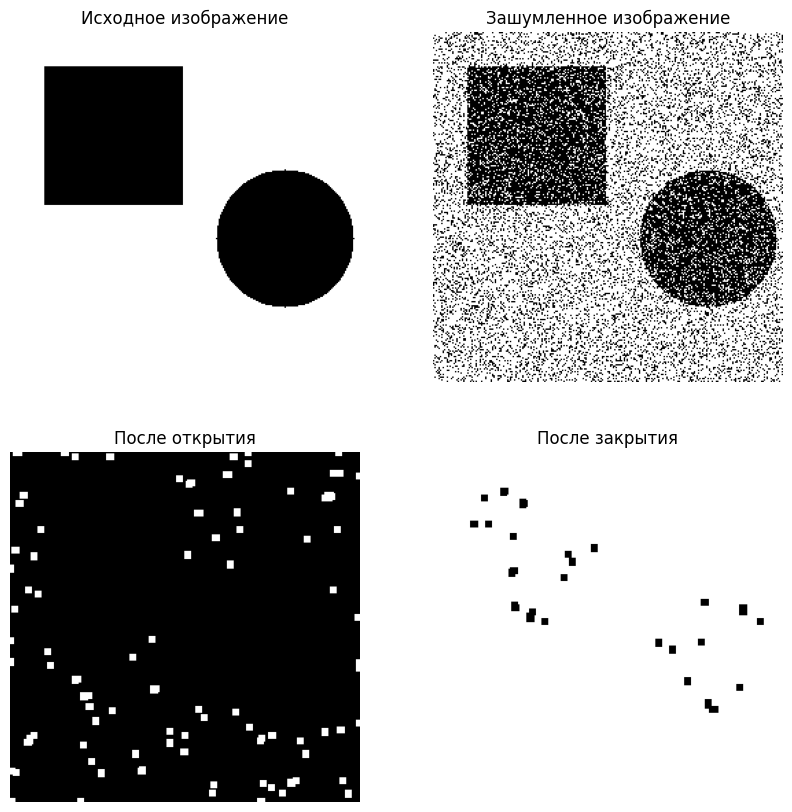

In [6]:
def opening(image: np.ndarray, struct: np.ndarray) -> np.ndarray:
    return dilatation2(erosion2(image, struct), struct)


def closing(image: np.ndarray, struct: np.ndarray) -> np.ndarray:
    return erosion2(dilatation2(image, struct), struct)


after_opening = opening(noisy_image, struct)
after_closing = closing(noisy_image, struct)

plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(noisy_image, cmap='gray')
plt.title('Зашумленное изображение')
plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(after_opening, cmap='gray')
plt.title('После открытия')
plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(after_closing, cmap='gray')
plt.title('После закрытия')
plt.axis('off')
plt.show()

### 5.1 Подсчёт коэффициента шума

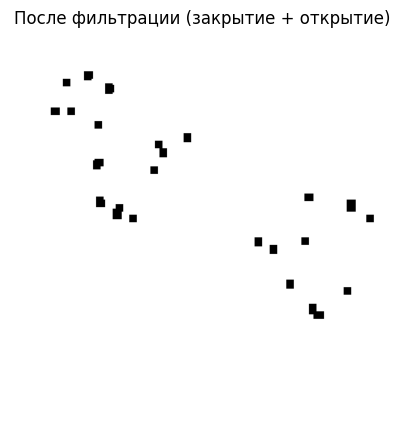

% плохих пикселей после зашумления: 19.89
% плохих пикселей после закрытия: 26.57
% плохих пикселей после закрытия и открытия: 26.57
% плохих пикселей после открытия: 68.78


In [7]:
after_closing_opening = opening(after_closing, struct)

plt.figure(figsize=(5, 5))
plt.subplot(1, 1, 1)
plt.imshow(after_closing_opening, cmap='gray')
plt.title('После фильтрации (закрытие + открытие)')
plt.axis('off')
plt.show()

print('% плохих пикселей после зашумления:',
      round(abs(image - noisy_image).sum() * 100 / np.prod(image.shape) / 255, 2))
print('% плохих пикселей после закрытия:',
      round(abs(image - after_closing).sum() * 100 / np.prod(image.shape) / 255, 2))
print('% плохих пикселей после закрытия и открытия:',
      round(abs(image - after_closing_opening).sum() * 100 / np.prod(image.shape) / 255, 2))
print('% плохих пикселей после открытия:',
      round(abs(image - after_opening).sum() * 100 / np.prod(image.shape) / 255, 2))

## 6. Выделение контуров объекта морфологическими операциями

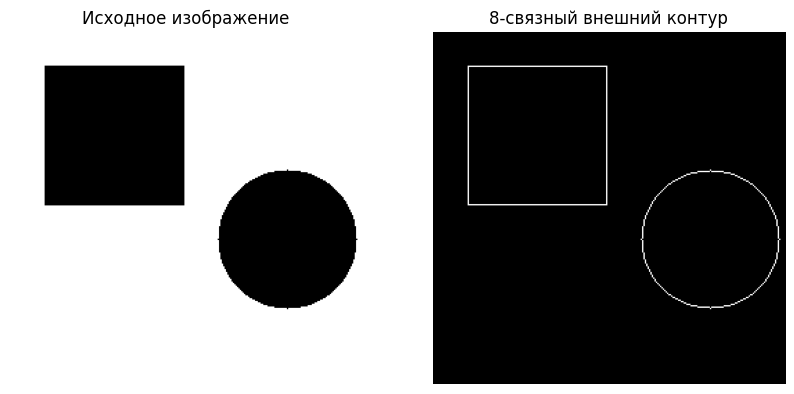

In [8]:
# 8-связный внешний контур (крест 3x3)
struct_cross = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
])

image_after_dilatation = dilatation2(image, struct_cross)
circuit_image = np.logical_xor(image, image_after_dilatation)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(circuit_image, cmap='gray')
plt.title('8-связный внешний контур')
plt.axis('off')
plt.show()

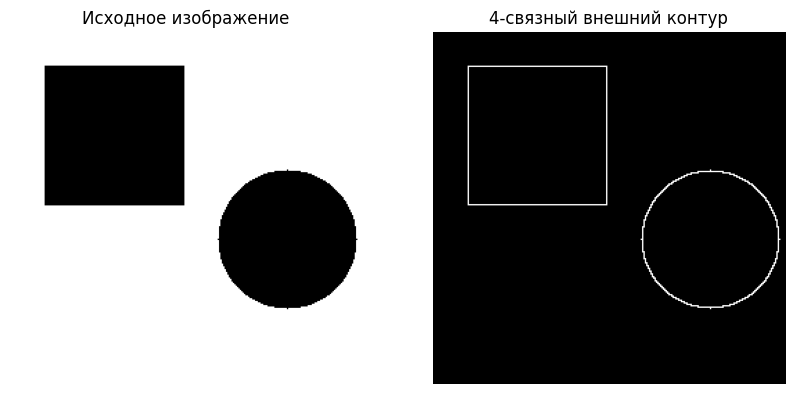

In [9]:
# 4-связный внешний контур (квадрат 3x3)
struct_square = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])

image_after_dilatation = dilatation2(image, struct_square)
circuit_image = np.logical_xor(image, image_after_dilatation)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(circuit_image, cmap='gray')
plt.title('4-связный внешний контур')
plt.axis('off')
plt.show()

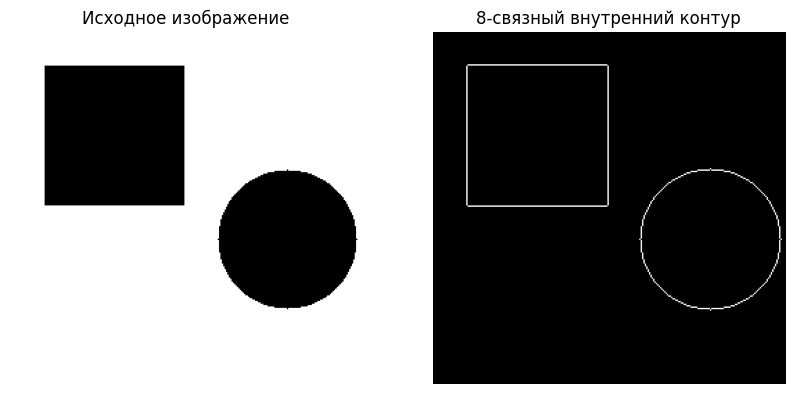

In [10]:
# 8-связный внутренний контур (крест 3x3)
struct_cross = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
])

image_after_erosion = erosion2(image, struct_cross)
circuit_image = np.logical_xor(image, image_after_erosion)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(circuit_image, cmap='gray')
plt.title('8-связный внутренний контур')
plt.axis('off')
plt.show()

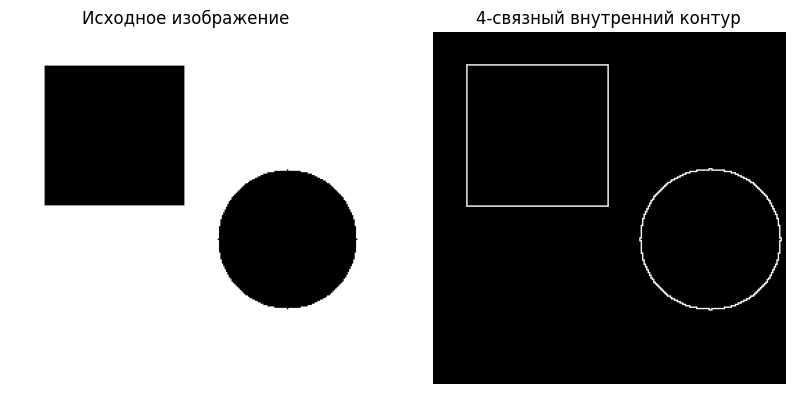

In [11]:
# 4-связный внутренний контур (квадрат 3x3)
struct_square = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])

image_after_erosion = erosion2(image, struct_square)
circuit_image = np.logical_xor(image, image_after_erosion)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(circuit_image, cmap='gray')
plt.title('4-связный внутренний контур')
plt.axis('off')
plt.show()

## 7. Выделение горизонтальных и вертикальных контуров

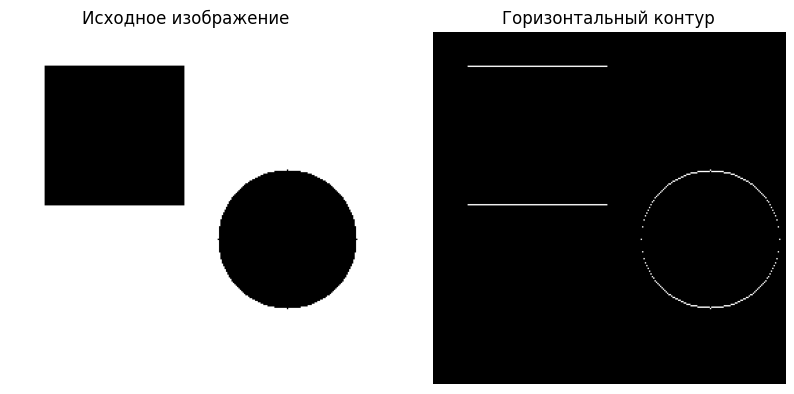

In [12]:
# Горизонтальный контур (вертикальный структурный элемент)
struct_vertical = np.array([
    [0, 1, 0],
    [0, 1, 0],
    [0, 1, 0]
])

image_after_dilatation = dilatation2(image, struct_vertical)
circuit_image = np.logical_xor(image, image_after_dilatation)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(circuit_image, cmap='gray')
plt.title('Горизонтальный контур')
plt.axis('off')
plt.show()

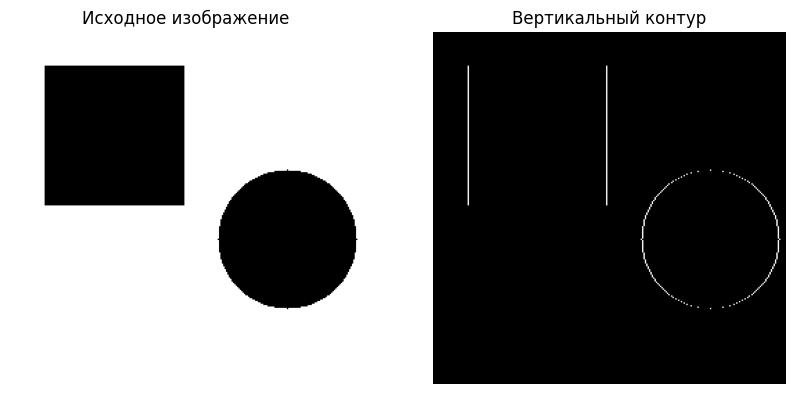

In [13]:
# Вертикальный контур (горизонтальный структурный элемент)
struct_horizontal = np.array([
    [0, 0, 0],
    [1, 1, 1],
    [0, 0, 0]
])

image_after_dilatation = dilatation2(image, struct_horizontal)
circuit_image = np.logical_xor(image, image_after_dilatation)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(circuit_image, cmap='gray')
plt.title('Вертикальный контур')
plt.axis('off')
plt.show()